In [18]:
import os
import json
from dotenv import load_dotenv
from typing import Annotated
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict
from langchain_mcp_adapters.client import MultiServerMCPClient

from agentevals.trajectory.match import create_trajectory_match_evaluator

load_dotenv()  # loads BLABLADOR_API_KEY from .env

# DeepEval tracing imports
# from deepeval.tracing import observe, update_current_span, update_current_trace  #for production monitoring
from deepeval.test_case import LLMTestCase, ToolCall
#from deepeval.tracing import get_trace_stack
from deepeval import evaluate
from deepeval.dataset import Golden
from deepeval.models import LiteLLMModel

from deepeval.metrics import (
    # RAG / Retrieval metrics
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualRecallMetric,
    ContextualPrecisionMetric,
    ContextualRelevancyMetric,

    # Agent / Tool metrics
    ToolCorrectnessMetric,
    TaskCompletionMetric,

    # General quality
    HallucinationMetric,
    BiasMetric,
)


In [19]:
BLABLADOR_BASE_URL = "https://api.helmholtz-blablador.fz-juelich.de/v1"
api_key=os.getenv("BLABLADOR_API_KEY")

Loaded 8 tools: ['get_current_time', 'unit_converter', 'search_web', 'text_stats', 'calculator', 'get_weather', 'ask_rdm', 'search_rdm']
Model ready.
Graph compiled successfully.


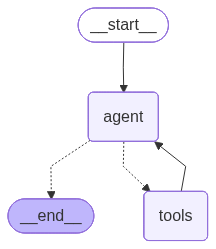

Q: What is (123 * 456) + 789?
A: {'answer': '\n\nThe result of (123 * 456) + 789 is 56,877.', 'messages': [HumanMessage(content='What is (123 * 456) + 789?', additional_kwargs={}, response_metadata={}, id='210c80b1-ffd5-4985-b84b-a6f1febbf0b0'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 928, 'total_tokens': 1068, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': '02 - Qwen3.5-122B-A10B-FP8, general purpose large model', 'system_fingerprint': None, 'id': 'chatcmpl-3488d5d5-9acc-4d6d-b444-82c9bbb568eb', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ea809-7c2a-72c3-8bb5-899b61713e8c-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '(123 * 456) + 789'}, 'id': 'chatcmpl-tool-b0514f0ac823ecfa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 928, 'output_tokens': 140, 'total_toke

In [3]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

BLABLADOR_BASE_URL = "https://api.helmholtz-blablador.fz-juelich.de/v1"

with open("mcp_config.json") as f:
    config = json.load(f)

    client = MultiServerMCPClient(config)
    tools = await client.get_tools()
    print(f"Loaded {len(tools)} tools: {[t.name for t in tools]}")

    llm = ChatOpenAI(
        model="alias-large",
        base_url=BLABLADOR_BASE_URL,
        api_key=api_key,
    )
    llm_with_tools = llm.bind_tools(tools)
    print("Model ready.")

    async def agent_node(state: AgentState) -> AgentState:
        response = await llm_with_tools.ainvoke(state["messages"])  # must await
        return {"messages": [response]}

    def build_graph():
        graph = StateGraph(AgentState)
        graph.add_node("agent", agent_node)
        graph.add_node("tools", ToolNode(tools))
        graph.add_edge(START, "agent")
        graph.add_conditional_edges("agent", tools_condition)
        graph.add_edge("tools", "agent")
        return graph.compile()

    app = build_graph()
    print("Graph compiled successfully.")

    try:
        from IPython.display import Image, display
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception:
        print(app.get_graph().draw_mermaid())
    
    async def run_with_trajectory(user_input: str) -> dict:
        result = await app.ainvoke({"messages": [HumanMessage(content=user_input)]})
        return {
            "answer": result["messages"][-1].content,
            "messages": result["messages"]  # full trajectory
        }

    queries = [
        "What is (123 * 456) + 789?",
        "What's the weather in Tokyo?",
        "What are the UFZ guidelines for long-term archiving?",
    ]

    for q in queries:
        print(f"Q: {q}")
        print(f"A: {await run_with_trajectory(q)}")   # must await async run()
        print()

## AGENT EVALS: Exact trajectory match 

In [4]:
# Example for: "What is (123 * 456) + 789?"
expected_math = [
    HumanMessage(content="What is (123 * 456) + 789?"),
    AIMessage(
        content="",
        tool_calls=[{
            "name": "calculator",        # the tool your agent should call
            "args": {"expression": "(123 * 456) + 789"},
            "id": "call_001"
        }]
    ),
    ToolMessage(content="56877", tool_call_id="call_001"),
    AIMessage(content="The result is 56,877."),
]

# Example for: "What's the weather in Tokyo?"
expected_weather = [
    HumanMessage(content="What's the weather in Tokyo?"),
    AIMessage(
        content="",
        tool_calls=[{
            "name": "get_weather",
            "args": {"city": "Tokyo"},
            "id": "call_002"
        }]
    ),
    ToolMessage(content="Sunny, 28°C", tool_call_id="call_002"),
    AIMessage(content="The weather in Tokyo is sunny and 28°C."),
]

In [10]:
evaluator = create_trajectory_match_evaluator(trajectory_match_mode="subset")

test_cases = [
    ("What is (123 * 456) + 789?",          expected_math),
    ("What's the weather in Tokyo?",          expected_weather),
    # add more as you build golden trajectories
]

results = []
for query, expected_messages in test_cases:
    output = await run_with_trajectory(query)
    result = evaluator(
        outputs={"messages": output["messages"]},
        reference_outputs={"messages": expected_messages}
    )
    results.append({
        "query": query,
        "passed": result["score"],
        "actual_tools": [
            m.tool_calls[0]["name"]
            for m in output["messages"]
            if hasattr(m, "tool_calls") and m.tool_calls
        ],
    })

for r in results:
    status = "✅" if r["passed"] else "❌"
    print(f"{status} {r['query']}")
    print(f"   Tools used: {r['actual_tools']}")

✅ What is (123 * 456) + 789?
   Tools used: ['calculator']
✅ What's the weather in Tokyo?
   Tools used: ['get_weather']


## DEEP-EVALS:  LLM-as-judge

In [28]:
#judge for evaluation metrics

Judge = LiteLLMModel(
    model="openai/alias-fast",          # prefix with "openai/" for OpenAI-compat APIs
    base_url=BLABLADOR_BASE_URL,
    api_key=os.getenv("BLABLADOR_API_KEY")
)

In [29]:
#React-agent

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    
with open("mcp_config.json") as f:
    config = json.load(f)

    client = MultiServerMCPClient(config)
    tools = await client.get_tools()
    print(f"Loaded {len(tools)} tools: {[t.name for t in tools]}")

    llm = ChatOpenAI(
        model="alias-large",
        base_url=BLABLADOR_BASE_URL,
        api_key=api_key,
    )
    llm_with_tools = llm.bind_tools(tools)
    print("Model ready.")

    async def agent_node(state: AgentState) -> AgentState:
        response = await llm_with_tools.ainvoke(state["messages"])  # must await
        return {"messages": [response]}

    def build_graph():
        graph = StateGraph(AgentState)
        graph.add_node("agent", agent_node)
        graph.add_node("tools", ToolNode(tools))
        graph.add_edge(START, "agent")
        graph.add_conditional_edges("agent", tools_condition)
        graph.add_edge("tools", "agent")
        return graph.compile()

    app = build_graph()
    print("Graph compiled successfully.")


Loaded 8 tools: ['get_current_time', 'unit_converter', 'search_web', 'text_stats', 'calculator', 'get_weather', 'ask_rdm', 'search_rdm']
Model ready.
Graph compiled successfully.


In [30]:
# agent execution function that extracts actual output, retrieval context, and tools called for evaluation

async def run_agent(user_input: str) -> dict:
    result = await app.ainvoke({"messages": [HumanMessage(content=user_input)]})
    messages = result["messages"]

    # 1. actual_output — last AIMessage that has content (not a tool call)
    actual_output = next(
        msg.content
        for msg in reversed(messages)
        if isinstance(msg, AIMessage) and msg.content
    )

    # 2. retrieval_context — what your tools returned
    retrieval_context = [
        str(msg.content) for msg in messages
        if isinstance(msg, ToolMessage)
    ]

    # 3. tools_called — pair each AIMessage tool call with its ToolMessage output
    tools_called = []
    tool_outputs = [msg for msg in messages if isinstance(msg, ToolMessage)]
    tool_idx = 0

    for msg in messages:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                output = tool_outputs[tool_idx].content if tool_idx < len(tool_outputs) else ""
                tools_called.append(ToolCall(
                    name=tc["name"],
                    input=tc["args"],
                    output=str(output),
                ))
                tool_idx += 1

    return {
        "actual_output": actual_output,
        "retrieval_context": retrieval_context,
        "tools_called": tools_called,
        "messages": messages,
    }

In [27]:
queries = [
    "What is (123 * 456) + 789?",
    "What are the requirements for long-term archiving?",
]

for q in queries:
    print(f"Q: {q}")
    print(f"A: {await run_agent(q)}")   # must await async run()
    print()
    

Q: What is (123 * 456) + 789?
A: {'actual_output': '\n\nThe result of (123 * 456) + 789 is **56,877**.', 'retrieval_context': ["[{'type': 'text', 'text': '56877', 'id': 'lc_e7772bfb-9789-4037-aad2-9082499944fd'}]"], 'tools_called': [ToolCall(
    name="calculator",
    output="[{'type': 'text', 'text': '56877', 'id': 'lc_e7772bfb-9789-4037-aad2-9082499944fd'}]"
)], 'messages': [HumanMessage(content='What is (123 * 456) + 789?', additional_kwargs={}, response_metadata={}, id='a348d260-9570-4c44-b43d-0f9549b53c46'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 928, 'total_tokens': 1039, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': '02 - Qwen3.5-122B-A10B-FP8, general purpose large model', 'system_fingerprint': None, 'id': 'chatcmpl-30fcefd6-d753-4d74-a79c-d1bf68c923cf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019

# TEST CASE 1 EVALUATION 

In [31]:
expected_output = (
    "for long-term archiving: Technical requirements: the service provider should "
    "have a strategy for data conversion and migration. In addition, a check of the "
    "readability of the files and a virus check should be carried out at regular "
    "intervals. All steps should be documented. Seal for trustworthy long-term "
    "archives: \"A digital long-term archive is considered trustworthy if it operates "
    "in accordance with its goals and specifications for information preservation over "
    "long periods of time and if its users, producers, operators, partners rely on it\". "
    "59 For an external assessment as to whether or to what extent a long-term archive "
    "is trustworthy, various seals with different focuses are developed, which do not "
    "address every type and operating model of repositories equally (e.g. Nestor seal, "
    "DIN 31644 or CoreTrustSeal). Cost of services: Always check whether service "
    "providers charge for data storage. The costs can depend, for example, on the "
    "amount of data, the implementation of technical standards or the affiliation of "
    "the data providers. Making the data accessible: Before choosing the storage "
    "location, you should ask yourself whether the data should be accessible or just "
    "stored. Longevity of the service provider: Economic and political factors "
    "influence the longevity of service providers."
)

In [40]:
# run your agent
output = await run_agent("What are the requirements for long-term archiving ?")

# build test case directly from output
test_case = LLMTestCase(
    input="What are the requirements for long-term archiving?",
    actual_output=output["actual_output"],
    expected_output= expected_output,  # your ground truth
    retrieval_context= output["retrieval_context"],
    context= output["retrieval_context"],
    tools_called=output["tools_called"]
)

In [33]:
faithfulness    = FaithfulnessMetric(threshold=0.7, model=Judge)
answer_rel      = AnswerRelevancyMetric(threshold=0.7, model=Judge)
task_completion = TaskCompletionMetric(threshold=0.7, model=Judge)
hallucination   = HallucinationMetric(threshold=0.5, model=Judge)

In [34]:
results = evaluate(
    test_cases=[test_case],
    metrics=[faithfulness, answer_rel, task_completion, hallucination]
)

✨ You're running DeepEval's latest Faithfulness Metric! (using openai/alias-fast (('alias-fast', 'openai', None, 
None)), strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using openai/alias-fast (('alias-fast', 'openai', 
None, None)), strict=False, async_mode=True)...

✨ You're running DeepEval's latest Task Completion Metric! (using openai/alias-fast (('alias-fast', 'openai', 
None, None)), strict=False, async_mode=True)...

✨ You're running DeepEval's latest Hallucination Metric! (using openai/alias-fast (('alias-fast', 'openai', None, 
None)), strict=False, async_mode=True)...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_0                                                                                                 │
│  ├──   Input:              What are the requirements for long-term archiving?                                   │
│  │     Actual Output:                                                                                           │
│  │                                                                                                              │
│  │                         Based on the UFZ Research Data Management (RDM) guidelines, the requirements for     │
│  │                         long-term archiving focus heavily on **documentation and metadata** to ensure        │
│  │                         data remains understandable, usable, and reproducible in the future.                 │
│  │                                                                                                              │
│  │                         Key requirements include:                                                            │
│  │                                                                                                              │
│  │                         *   **Comprehensive Metadata**: You must provide precise descriptions of             │
│  │                         variables (what they are, how they are coded, etc.). This information should be      │
│  │                         formatted as standardized technical and specialized metadata.                        │
│  │                         *   **Understandability and Consistency**: All information included in the           │
│  │                         archive must be clear, consistent, and free of ambiguity.                            │
│  │                         *   **Trustworthiness**: The source of the data must be trustworthy and              │
│  │                         verifiable.                                                                          │
│  │                         *   **Reproducibility**: The documentation must be sufficient to allow others to     │
│  │                         understand the data and reproduce the research results.                              │
│  │                                                                                                              │
│  │                         Essentially, without proper metadata and clear documentation, data cannot be         │
│  │                         effectively archived for long-term use.                                              │
│  │     Expected Output:    for long-term archiving: Technical requirements: the service provider should have    │
│  │                         a strategy for data conversion and migration. In addition, a check of the            │
│  │                         readability of the files and a virus check should be carried out at regular          │
│  │                         intervals. All steps should be documented. Seal for trustworthy long-term            │
│  │                         archives: "A digital long-term archive is considered trustworthy if it operates      │
│  │                         in accordance with its goals and specifications for information preservation over    │
│  │                         long periods of time and if its users, producers, operators, partners rely on        │
│  │                         it". 59 For an external asses

⚠ WARNING: No hyperparameters logged.
» ]8;id=16367587;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 12.71s | token cost: 1.6484999999999999 USD)
» Test Results (1 total tests):
   » Pass Rate: 0.0% | Passed: 0 | Failed: 1

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

In [ ]:
input_question = "what is research data management plan?"


In [43]:
expected_output1 = (
    "A data management plan (DMP) describes the intended treatment, "
    "of research data. This includes activities during the research process, "
    "as well as after completion. The DMP contains all information describing and documenting, "
    "the collection, preparation, storage, archiving and publication, "
    "of research data. In length, a DMP can vary from a few paragraphs to several pages."
)

In [45]:
output = await run_agent(input_question)

# build test case directly from output
test_case2 = LLMTestCase(
    input=input_question,
    actual_output=output["actual_output"],
    expected_output= expected_output1,  # your ground truth
    retrieval_context= output["retrieval_context"],
    context= output["retrieval_context"],
    tools_called=output["tools_called"]
)

In [46]:
results = evaluate(
    test_cases=[test_case],
    metrics=[faithfulness, answer_rel, task_completion, hallucination]
)

✨ You're running DeepEval's latest Faithfulness Metric! (using openai/alias-fast (('alias-fast', 'openai', None, 
None)), strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using openai/alias-fast (('alias-fast', 'openai', 
None, None)), strict=False, async_mode=True)...

✨ You're running DeepEval's latest Task Completion Metric! (using openai/alias-fast (('alias-fast', 'openai', 
None, None)), strict=False, async_mode=True)...

✨ You're running DeepEval's latest Hallucination Metric! (using openai/alias-fast (('alias-fast', 'openai', None, 
None)), strict=False, async_mode=True)...

c:\Users\abdul\langgraph-agent\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_0                                                                                                 │
│  ├──   Input:              What are the requirements for long-term archiving?                                   │
│  │     Actual Output:                                                                                           │
│  │                                                                                                              │
│  │                         Based on the UFZ Research Data Management (RDM) guidelines, the key requirements     │
│  │                         for long-term archiving focus on ensuring that data remains **understandable,        │
│  │                         usable, and reproducible** in the future.                                            │
│  │                                                                                                              │
│  │                         Here are the primary requirements:                                                   │
│  │                                                                                                              │
│  │                         *   **Comprehensive Documentation & Metadata:**                                      │
│  │                             *   You must provide precise descriptions of all variables, including what       │
│  │                         they represent and how they are coded.                                               │
│  │                             *   This information should be structured as **standardized technical and        │
│  │                         specialized metadata**.                                                              │
│  │                             *   The documentation must ensure that all information is consistent and         │
│  │                         understandable without the original researcher present.                              │
│  │                                                                                                              │
│  │                         *   **Data Quality & Trustworthiness:**                                              │
│  │                             *   The data source must be trustworthy.                                         │
│  │                             *   The data should be analyzed and prepared for future use.                     │
│  │                                                                                                              │
│  │                         *   **Reproducibility:**                                                             │
│  │                             *   The documentation and metadata are a prerequisite for the reproducibility    │
│  │                         of research results.                                                                 │
│  │                                                                                                              │
│  │                         *   **Technical Considerations (for Apps/Software):**                                │
│  │                             *   If archiving software or apps, you must specify the access address           │
│  │                         (internal vs. external).                                                             │
│  │                             *   Document any required

⚠ WARNING: No hyperparameters logged.
» ]8;id=16367589;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 14.05s | token cost: 1.9015000000000002 USD)
» Test Results (1 total tests):
   » Pass Rate: 0.0% | Passed: 0 | Failed: 1

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.